<a href="https://colab.research.google.com/github/keinlika/Asteroid/blob/main/notebooks/starter_bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
# Cell 1: Load data (train)
import pandas as pd
import numpy as np

# Use the course URL or replace with your own upload path
TRAIN_URL = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv"

train = pd.read_csv(TRAIN_URL)
print("Train shape:", train.shape)
train.head()

Train shape: (37069, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [71]:
# Cell 2: Schema + NO row drops

TARGET_COL = "y"

# Fixed columns
NUMERIC_BASE = [
    "age","campaign","pdays","previous",
    "emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"
]
CATEGORICAL_BASE = [
    "job","marital","education","default","housing","loan",
    "contact","month","day_of_week","poutcome"
]

# Be robust to occasional extra columns
extra_numeric = train.select_dtypes(include=[np.number]).columns.difference(NUMERIC_BASE + [TARGET_COL]).tolist()
extra_cats = train.select_dtypes(exclude=[np.number]).columns.difference(CATEGORICAL_BASE + [TARGET_COL]).tolist()

NUMERIC_COLS = [c for c in NUMERIC_BASE + extra_numeric if c in train.columns]
CATEGORICAL_COLS = [c for c in CATEGORICAL_BASE + extra_cats if c in train.columns]

missing = [c for c in NUMERIC_BASE + CATEGORICAL_BASE + [TARGET_COL] if c not in train.columns and c in NUMERIC_BASE + CATEGORICAL_BASE + [TARGET_COL]]
print("Missing expected columns:", missing)

# Map target to 0/1 (handles "yes/no", "y/n", bool)
train[TARGET_COL] = pd.Series(train[TARGET_COL]).map({"yes":1,"y":1,True:1,"no":0,"n":0,False:0}).astype(int)

def add_engineered_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Flag "never contacted before" (pdays==999)
    if "pdays" in df.columns:
        df["never_contacted"] = (df["pdays"] == 999).astype(int)
    else:
        df["never_contacted"] = 0
    # Light bins (kept as extra categoricals; originals remain)
    if "campaign" in df.columns:
        df["campaign_bin"] = pd.cut(df["campaign"], bins=[-1,1,2,3,5,10,1000],
                                    labels=["1","2","3","4-5","6-10",">10"])
    else:
        df["campaign_bin"] = "unknown"
    if "pdays" in df.columns:
        df["pdays_bin"] = pd.cut(df["pdays"], bins=[-np.inf,0,5,30,90,998,999,np.inf],
                                 labels=["<=0","1-5","6-30","31-90","91-998","999",">999"])
    else:
        df["pdays_bin"] = "unknown"
    return df

train_fe = add_engineered_cols(train)

# Final feature lists
NUMERIC_COLS_FE = NUMERIC_COLS + ["never_contacted"]
CATEGORICAL_COLS_FE = CATEGORICAL_COLS + ["campaign_bin","pdays_bin"]

print("Numeric:", NUMERIC_COLS_FE)
print("Categorical:", CATEGORICAL_COLS_FE)
train_fe[[TARGET_COL] + NUMERIC_COLS_FE + CATEGORICAL_COLS_FE].head()

Missing expected columns: []
Numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'campaign_bin', 'pdays_bin']


,y,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,education,default,housing,loan,contact,month,day_of_week,poutcome,campaign_bin,pdays_bin
0,0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,basic.4y,no,no,no,telephone,may,mon,nonexistent,1,999
1,0,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,high.school,unknown,no,no,telephone,may,mon,nonexistent,1,999
2,0,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,high.school,no,yes,no,telephone,may,mon,nonexistent,1,999
3,0,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,basic.6y,no,no,no,telephone,may,mon,nonexistent,1,999
4,0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,high.school,no,no,yes,telephone,may,mon,nonexistent,1,999


In [80]:
# Cell 3: Preprocessing pipeline + train split (OHE)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

RANDOM_STATE = 42

X = train_fe[NUMERIC_COLS_FE + CATEGORICAL_COLS_FE]
y = train_fe[TARGET_COL]

num_pre = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

# OneHotEncoder
def make_ohe():
    try:
        # scikit-learn ≥ 1.4 uses 'sparse_output'
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # scikit-learn ≤ 1.3 uses 'sparse'
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pre = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", make_ohe()),
])

preprocessor = ColumnTransformer([
    ("num", num_pre, NUMERIC_COLS_FE),
    ("cat", cat_pre, CATEGORICAL_COLS_FE),
], remainder="drop")

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_valid.shape

((29655, 22), (7414, 22))

In [73]:
# Cell 4: Baseline Decision Tree + 5-fold CV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, classification_report

pipe_dt = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy","precision","recall","f1","roc_auc"]
cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

{m: round(cv_dt[f"test_{m}"].mean(), 3) for m in ["accuracy","precision","recall","f1","roc_auc"]}

{'accuracy': np.float64(0.841),
 'precision': np.float64(0.315),
 'recall': np.float64(0.342),
 'f1': np.float64(0.328),
 'roc_auc': np.float64(0.624)}

In [74]:
# Cell 5 — Fit DT and evaluate on validation
pipe_dt.fit(X_train, y_train)
valid_pred_dt = pipe_dt.predict(X_valid)
valid_proba_dt = pipe_dt.predict_proba(X_valid)[:, 1]

print("DT  F1:", round(f1_score(y_valid, valid_pred_dt), 3))
print("DT  ROC-AUC:", round(roc_auc_score(y_valid, valid_proba_dt), 3))
print("\nDT Classification report:\n", classification_report(y_valid, valid_pred_dt))

DT  F1: 0.333
DT  ROC-AUC: 0.626

DT Classification report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      6572
           1       0.32      0.34      0.33       842

    accuracy                           0.84      7414
   macro avg       0.62      0.63      0.62      7414
weighted avg       0.85      0.84      0.85      7414



In [75]:
# Cell 6: train a single strong Random Forest (no tuning loop)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# config: balanced, moderate depth, subsampled trees for speed
try:
    rf_fast = RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        bootstrap=True,
        max_samples=0.6,      # subsample per tree for speed
        n_jobs=-1,
        random_state=42,
    )
except TypeError:
    # Older sklearn without max_samples
    rf_fast = RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )

final_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", rf_fast),
])

final_pipeline.fit(X_train, y_train)
print("RF (fast) trained.")

RF (fast) trained.


In [76]:
# Cell 7: Evaluate final RF + optional threshold sweep

from sklearn.metrics import f1_score, roc_auc_score, classification_report, precision_score, recall_score
import numpy as np

# Validate
valid_proba_rf = final_pipeline.predict_proba(X_valid)[:, 1]
valid_pred_rf = final_pipeline.predict(X_valid)

print("RF  F1:", round(f1_score(y_valid, valid_pred_rf), 3))
print("RF  ROC-AUC:", round(roc_auc_score(y_valid, valid_proba_rf), 3))
print("\nRF Classification report:\n", classification_report(y_valid, valid_pred_rf))

# Optional: choose a custom threshold by F1 (fast sweep)
def best_threshold_f1(y_true, y_proba, ts=np.linspace(0.05, 0.95, 19)):
    best_t, best_f1 = 0.5, -1
    rows = []
    for t in ts:
        yhat = (y_proba >= t).astype(int)
        f1  = f1_score(y_true, yhat)
        prec = precision_score(y_true, yhat, zero_division=0)
        rec  = recall_score(y_true, yhat)
        rows.append((round(t,2), round(f1,3), round(prec,3), round(rec,3)))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print("\nThreshold sweep (t, F1, Precision, Recall) top 5:")
    for r in sorted(rows, key=lambda x: x[1], reverse=True)[:5]:
        print(r)
    return best_t, best_f1

suggested_t, best_f1 = best_threshold_f1(y_valid, valid_proba_rf)
print(f"\nSuggested threshold by F1: {suggested_t:.2f}  (F1={best_f1:.3f})")

# Lock this if you want a custom cutoff; else keep None to use .predict()
FINAL_THRESHOLD = 0.55

RF  F1: 0.508
RF  ROC-AUC: 0.8

RF Classification report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93      6572
           1       0.45      0.58      0.51       842

    accuracy                           0.87      7414
   macro avg       0.70      0.74      0.72      7414
weighted avg       0.89      0.87      0.88      7414


Threshold sweep (t, F1, Precision, Recall) top 5:
(np.float64(0.55), 0.514, 0.477, 0.558)
(np.float64(0.6), 0.513, 0.507, 0.519)
(np.float64(0.5), 0.508, 0.453, 0.578)
(np.float64(0.45), 0.499, 0.424, 0.607)
(np.float64(0.65), 0.494, 0.53, 0.463)

Suggested threshold by F1: 0.55  (F1=0.514)


In [77]:
# Cell 8: Save model for deployment (pipeline + preprocessing)
import pickle
TEAM_NUMBER = "3"  # <-- set yours

MODEL_PATH = f"team{TEAM_NUMBER}-module2-model.pkl"
with open(MODEL_PATH, "wb") as f:
    pickle.dump(final_pipeline, f, protocol=5)

print("Saved model:", MODEL_PATH)


Saved model: team3-module2-model.pkl


In [78]:
# Cell 9: MINI holdout predictions (header 'y')
MINI_URL = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test_mini.csv"

mini = pd.read_csv(MINI_URL)
mini_fe = add_engineered_cols(mini)

if FINAL_THRESHOLD is None:
    mini_preds = final_pipeline.predict(mini_fe).astype(int)
else:
    mini_proba = final_pipeline.predict_proba(mini_fe)[:, 1]
    mini_preds = (mini_proba >= FINAL_THRESHOLD).astype(int)

mini_csv = f"team{TEAM_NUMBER}-module2-mini.csv"
pd.DataFrame({"y": mini_preds}).to_csv(mini_csv, index=False)
print("Wrote:", mini_csv, "| rows:", len(mini_preds))

Wrote: team3-module2-mini.csv | rows: 410


In [81]:
# Cell 10: FULL holdout predictions (header 'predictions')
FULL_URL = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test.csv"

full_ = pd.read_csv(FULL_URL)
assert len(full_) == 4119, f"Expected 4,119 rows; got {len(full_)}"

full_fe = add_engineered_cols(full_)

if FINAL_THRESHOLD is None:
    full_preds = final_pipeline.predict(full_fe).astype(int)
else:
    full_proba = final_pipeline.predict_proba(full_fe)[:, 1]
    full_preds = (full_proba >= FINAL_THRESHOLD).astype(int)

full_csv = f"team{TEAM_NUMBER}-module2-predictions.csv"
pd.DataFrame({"predictions": full_preds}).to_csv(full_csv, index=False)
print("Wrote:", full_csv, "| rows:", len(full_preds))

Wrote: team3-module2-predictions.csv | rows: 4119


In [83]:
# Cell 11: Feature names after preprocessing (robust)

import numpy as np

def get_fitted_preprocessor():
    """
    Return a FITTED ColumnTransformer.
    Prefer the one inside your trained pipelines (final_pipeline or pipe_dt).
    """
    if 'final_pipeline' in globals():
        return final_pipeline.named_steps["prep"]
    elif 'pipe_dt' in globals():
        # if you've already fit pipe_dt, use that
        return pipe_dt.named_steps["prep"]
    else:
        # As a last resort, fit the raw preprocessor on X_train
        global preprocessor
        preprocessor.fit(X_train)  # fits on training features only
        return preprocessor

fitted_prep = get_fitted_preprocessor()

def get_feature_names(fitted_preprocessor, num_cols, cat_cols):
    names = []
    # numeric columns (pass-through via numeric pipeline)
    names.extend(num_cols)

    # categorical OHE names
    ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["ohe"]

    # sklearn >=1.0 usually has get_feature_names_out
    try:
        cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    except Exception:
        # fallback: build manually from categories_ (older versions)
        cat_names = []
        for col, cats in zip(cat_cols, ohe.categories_):
            cat_names.extend([f"{col}_{c}" for c in cats])

    names.extend(cat_names)
    return names

FEATURE_NAMES = get_feature_names(fitted_prep, NUMERIC_COLS_FE, CATEGORICAL_COLS_FE)
print(len(FEATURE_NAMES), "features; first 10:", FEATURE_NAMES[:10])


73 features; first 10: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted']


In [90]:
# Helper: get indices for any list of feature names safely
def indices_for(names, all_names):
    idx = []
    missing = []
    for n in names:
        if n in all_names:
            idx.append(all_names.index(n))
        else:
            missing.append(n)
    if missing:
        print("Skipping missing features:", missing)
    return idx

# swap index
numeric_targets = ["campaign", "pdays", "euribor3m"]
target_indices = indices_for(numeric_targets, FEATURE_NAMES)

# DT fitted
pipe_dt.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'never_contacted']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'campaign_bin',
                                                   'pdays_bin'])])),
                ('clf',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

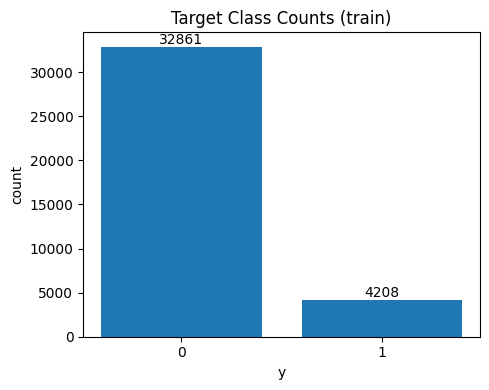

Overall positive rate (train): 11.352%


In [91]:
# Cell 19: Class balance
import matplotlib.pyplot as plt

y_counts = y.value_counts().sort_index()  # 0 then 1
plt.figure(figsize=(5,4))
plt.bar(['0','1'], [int(y_counts.get(0,0)), int(y_counts.get(1,0))])
plt.title("Target Class Counts (train)")
plt.xlabel("y")
plt.ylabel("count")
for i, v in enumerate([int(y_counts.get(0,0)), int(y_counts.get(1,0))]):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

pos_rate = y.mean()
print(f"Overall positive rate (train): {pos_rate:.3%}")

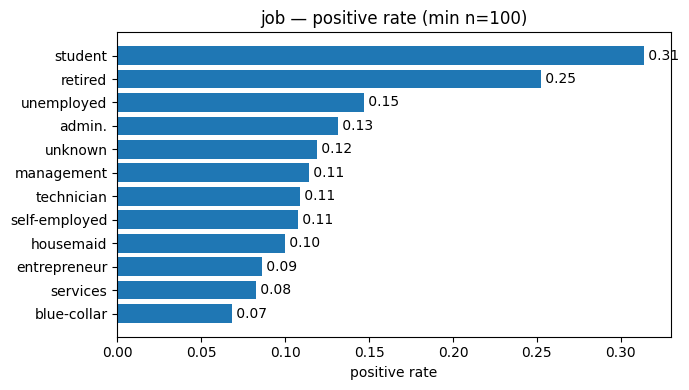

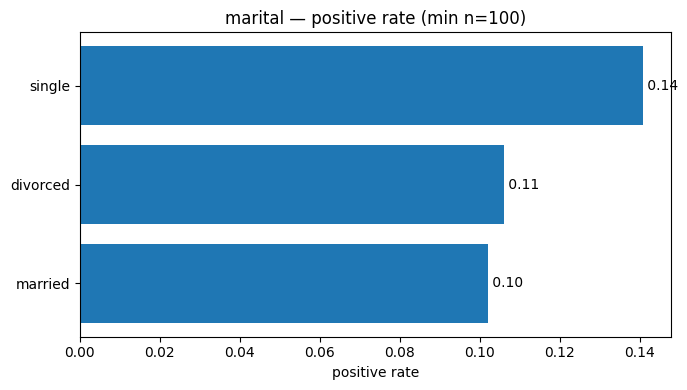

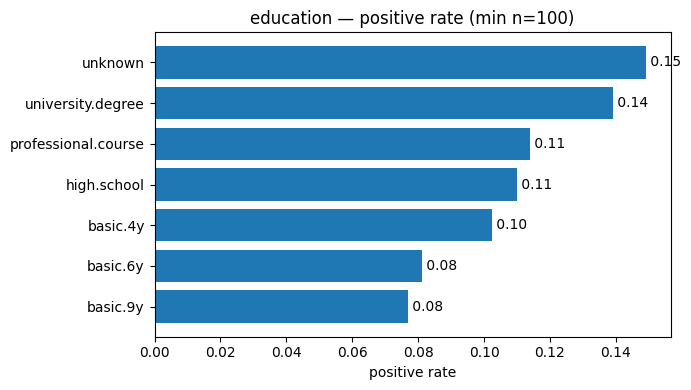

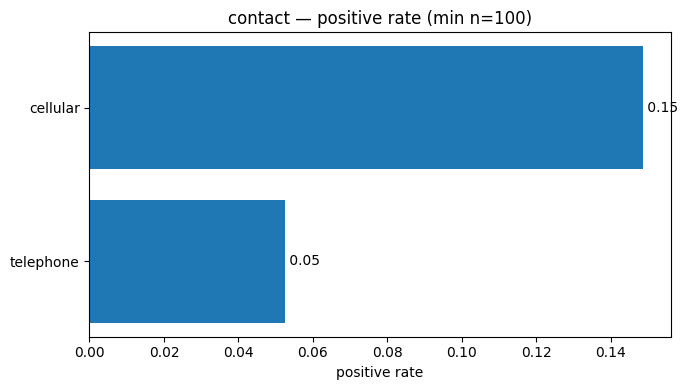

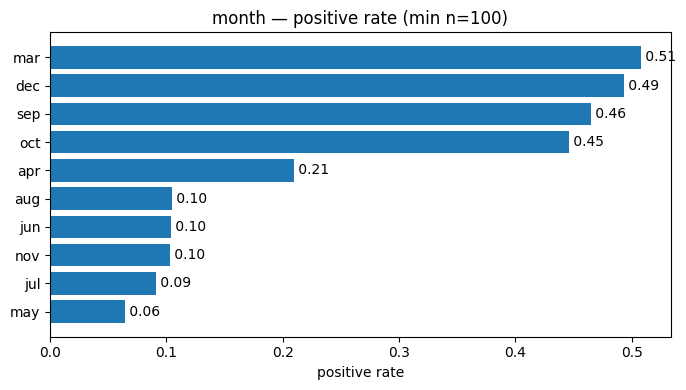

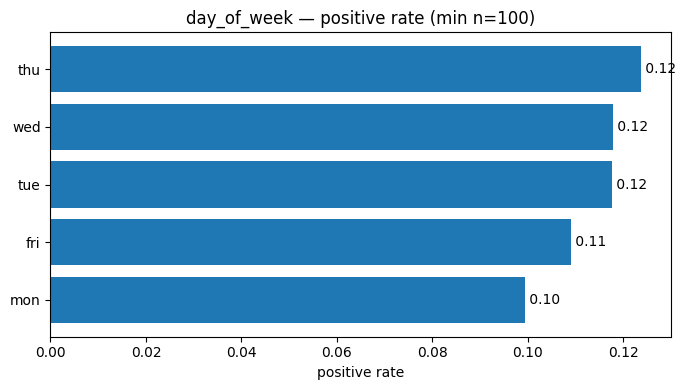

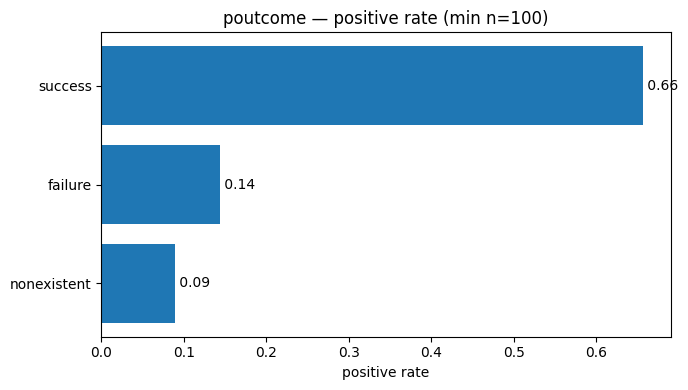

In [94]:
# Cell 22: Category positive rates
import pandas as pd
import matplotlib.pyplot as plt

cat_cols_to_view = ["job","marital","education","contact","month","day_of_week","poutcome"]

def plot_pos_rate(col, min_count=100, top_k=12):
    df = train_fe[[col, TARGET_COL]].copy()
    rate = (df.groupby(col)[TARGET_COL]
              .agg(['mean','count'])
              .sort_values('mean', ascending=False))
    rate = rate[rate['count'] >= min_count].head(top_k)
    plt.figure(figsize=(7,4))
    plt.barh(rate.index.astype(str), rate['mean'])
    plt.gca().invert_yaxis()
    plt.xlabel("positive rate")
    plt.title(f"{col} — positive rate (min n={min_count})")
    for i, v in enumerate(rate['mean'].values):
        plt.text(v, i, f" {v:.2f}", va='center')
    plt.tight_layout()
    plt.show()

for c in cat_cols_to_view:
    if c in train_fe.columns:
        plot_pos_rate(c, min_count=100, top_k=12)

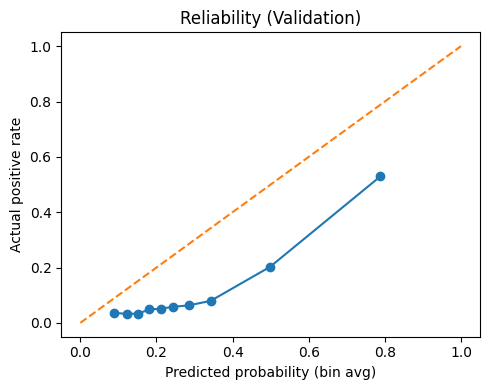

In [97]:
# Cell 25: Calibration-style reliability plot on validation
from sklearn.calibration import calibration_curve

proba = final_pipeline.predict_proba(X_valid)[:,1]
true, pred = calibration_curve(y_valid, proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(5,4))
plt.plot(pred, true, marker='o')
plt.plot([0,1], [0,1], '--')
plt.xlabel("Predicted probability (bin avg)")
plt.ylabel("Actual positive rate")
plt.title("Reliability (Validation)")
plt.tight_layout()
plt.show()